## Analysis on selected regions with increased local density of T cells

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import os

In [2]:
# Set working directory to save files
new_directory = "/homevol/huemail/G000428_MaiLa/Xenium_repeated_n8_probev2/Lymphoids"
os.chdir(new_directory)

In [9]:
imm_065_480 = sc.read_h5ad("MH065_480_ss_cropped_immune#1.h5ad")
imm_107_480 = sc.read_h5ad("MH107_480_ss_cropped_immune#1.h5ad")
imm_106_480 = sc.read_h5ad("MH106_480_ss_cropped_immune#1.h5ad")
imm_106_314 = sc.read_h5ad("Fig5_0010617_Region3_Immune_ss_Jun25.h5ad")

In [7]:
import pandas as pd

# adata  lists
imm_list = [imm_065_480, imm_107_480, imm_106_480, imm_106_314]
imm_names = ["TIL_MH065_480", "TIL_MH107_480", "TIL_MH106_480", "TIL_MH106_314"]

# Cell types to count
cell_types = ["CD4 T cells", "CD8 T cells", "CD8 TRM", "CD4 Treg","NK"]

# Data structure to store counts
summary = []

# Collect counts for each sample
for name, adata in zip(imm_names, imm_list):
    counts = {"Sample": name, "Total Cells": adata.n_obs}
    for cell_type in cell_types:
        if "cell_class_threshold" in adata.obs.columns:
            counts[cell_type] = (adata.obs["cell_class_threshold"] == cell_type).sum()
        else:
            counts[cell_type] = 0
    summary.append(counts)

# Create DataFrame
df_summary = pd.DataFrame(summary)

# Add a total row
total_row = {
    "Sample": "Total (All Samples)",
    "Total Cells": df_summary["Total Cells"].sum()
}
for cell_type in cell_types:
    total_row[cell_type] = df_summary[cell_type].sum()

# Append total to the summary
df_summary = pd.concat([df_summary, pd.DataFrame([total_row])], ignore_index=True)

# Display
print(df_summary)

                Sample  Total Cells  CD4 T cells  CD8 T cells  CD8 TRM  \
0        TIL_MH065_480        10928          640          615      141   
1        TIL_MH107_480        21695         1030          846       76   
2        TIL_MH106_480         9081          559          308       21   
3        TIL_MH106_314        39875         1922          735       20   
4  Total (All Samples)        81579         4151         2504      258   

   CD4 Treg   NK  
0       183   94  
1        78  113  
2        83   72  
3       260  168  
4       604  447  


In [ ]:
## Each TIL was analysed seperately 

In [15]:
manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG':'#17becf',
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "Other": "#cccccc",
    'Stromal_CCL19':"#BBDA8F"}

for adata in imm_list:
    cats = adata.obs['cell_class_threshold'].cat.categories
    adata.uns['cell_class_threshold_colors'] = [
        manual_colors[ct] for ct in cats
    ]

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

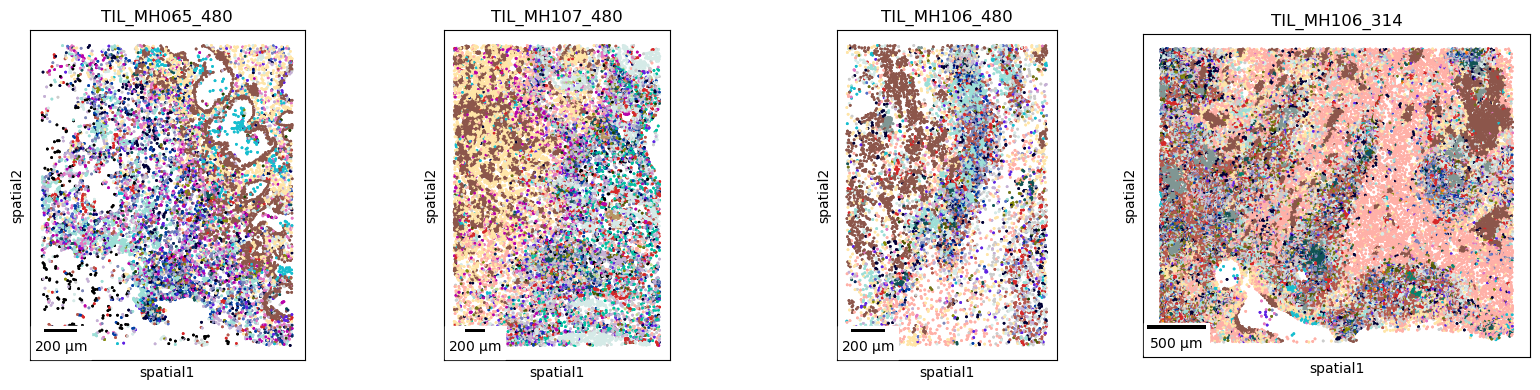

In [ ]:
import matplotlib.pyplot as plt
import squidpy as sq

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for adata, name, ax in zip(imm_list, imm_names, axes):
    sq.pl.spatial_scatter(
        adata,
        shape=None,
        color='cell_class_threshold',
        size=4,
        library_id='spatial',
        ax=ax,  # assign axis
        title=name,
        legend_loc=None,
        scalebar_dx=1.0,
        scalebar_kwargs={
            "scale_loc": "bottom",
            "location": "lower left"
        }
    )

plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine TIL data
imm_data = {
    "TIL_MH106_314": imm_106_314.obs["cell_class_threshold"],
    "TIL_MH065_480": imm_065_480.obs["cell_class_threshold"],
    "TIL_MH107_480": imm_107_480.obs["cell_class_threshold"],
    "TIL_MH106_480": imm_106_480.obs["cell_class_threshold"]
}

# Build long-form DataFrame
df_all = pd.concat(
    [pd.DataFrame({"Sample": imm_id, "cell_type": values}) for imm_id, values in imm_data.items()],
    ignore_index=True
)

In [20]:
til_presence = df_all.groupby("cell_type")["Sample"].nunique()

In [22]:
consistent_cell_types = [
    c for c in til_presence[til_presence >= 3].index
    if c not in ['Unclassified', 'Unassigned']
]

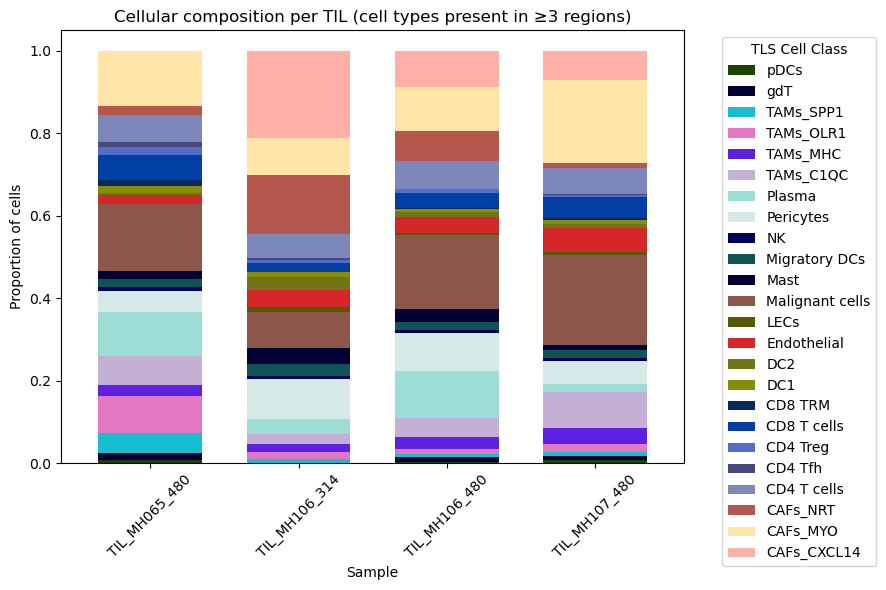

In [23]:
df_filtered = df_all[df_all["cell_type"].isin(consistent_cell_types)]

# Count & normalize 
comp = (
    df_filtered.groupby(["Sample", "cell_type"])
    .size()
    .reset_index(name="count")
)

comp["proportion"] = comp.groupby("Sample")["count"].transform(lambda x: x / x.sum())

# Pivot for plotting
pivot = comp.pivot(index="Sample", columns="cell_type", values="proportion").fillna(0)

# order classes
ordered_classes = consistent_cell_types
pivot = pivot[ordered_classes[::-1]]  # reverse for stacking order

#Color map - as above
color_map = {
    'Acinar': '#ffb500',
    'Acinar_REG':'#17becf',
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    'Stromal_CCL19': '#D8D18C', 
    "Other": "#cccccc"
}

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6),
    width=0.7,
    color=[color_map[c] for c in pivot.columns]
)

plt.ylabel("Proportion of cells")
plt.title("Cellular composition per TIL (cell types present in ≥3 regions)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='TLS Cell Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"TIL_comp.pdf")
plt.show()

#### Neighbourhood profiling 

In [29]:
results_by_sample = {}

# Loop over all samples
for adata, sample_name in zip(imm_list, imm_names):
    print(f"Processing {sample_name}...")

    df = analyze_neighbors_avg_per_cell_type(
        adata=adata,
        center_label="CD8 T cells", # repeat and do the same for CD4, CD4Treg, CD8, CD8TRM
        radius=50,
        label_key="cell_class_threshold",
        spatial_key="spatial"
    )

    results_by_sample[sample_name] = df

Processing TIL_MH065_480...
Processing TIL_MH107_480...
Processing TIL_MH106_480...
Processing TIL_MH106_314...


/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

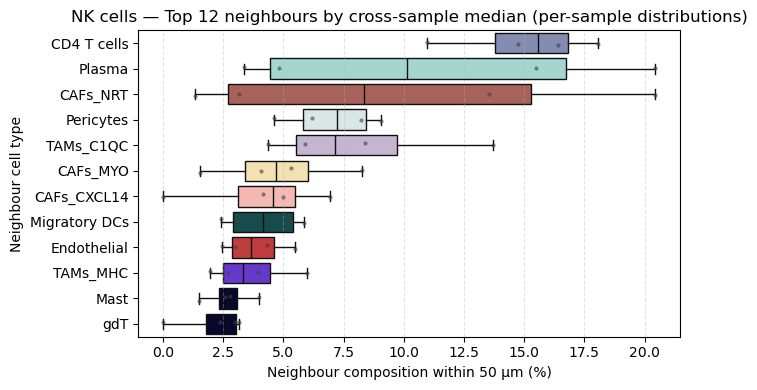

In [30]:
# Stack to samples x neighbors
# results_by_sample: {'MH065_314': Series(...), 'MH074_314': Series(...), ...}
wide = pd.DataFrame(results_by_sample).T  # rows = samples, cols = neighbors (fractions)
wide = wide.fillna(0)

if any(col.endswith("_mean") for col in wide.columns):
    wide = wide[[c for c in wide.columns if c.endswith("_mean")]].copy()
    wide.columns = [c[:-5] for c in wide.columns]  # remove "_mean"

# Drop unwanted labels
wide = wide.drop(columns=[c for c in ["Unclassified", "Unassigned"] if c in wide.columns], errors="ignore")
wide_pct = wide * 100

# Rank neighbors by median across samples
med_across_samples = wide_pct.median(axis=0).sort_values(ascending=False)

# Keep top cell classes
topk = med_across_samples.head(min(12, len(med_across_samples))).index.tolist()

long = (
    wide_pct[topk]
    .reset_index()
    .rename(columns={"index": "sample"})
    .melt(id_vars="sample", var_name="neighbor", value_name="percent")
)

# Order neighbors by their cross-sample median
order = med_across_samples.loc[topk].index.tolist()

# Boxplot 
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=long, x="percent", y="neighbor",
    palette=manual_colors,
    order=order, fliersize=2, linewidth=1
)
sns.stripplot(
    data=long, x="percent", y="neighbor",
    order=order, color=".25", size=3, jitter=True, alpha=0.6
)
plt.xlabel("Neighbour composition within 50 µm (%)")
plt.ylabel("Neighbour cell type")
plt.title("CD8 T cells — Top 12 neighbours by cross-sample median (per-sample distributions)")
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

In [81]:
toplot_107_480 = imm_107_480[imm_107_480.obs['cell_class_threshold'].isin(['CD4 T cells',
 'CD4 Treg', 'CD8 T cells', 'CD8 TRM','Malignant cells'])]

In [86]:
genes_anno = ['CXCR4','CD3E','CD3D','IL7R','TCF7',#'SELL','LEF1',
              'CD247','FOXP3','CCR8','CTLA4','TIGIT','CD8A','CD8B','GZMA','CCL4','CCL5','GZMK','GZMB','ITGAE','CXCR6','CD226','KLRC1','KLRK1','KLRD1','PVR','TNFRSF14']

/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/homevol/huemail/.local/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


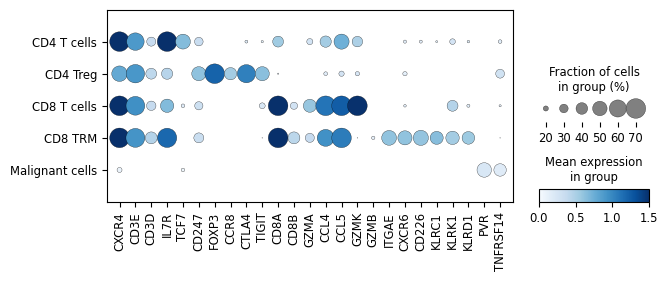

In [87]:
sc.pl.dotplot(toplot_107_480, var_names = genes_anno, groupby='cell_class_threshold', #swap_axes = True, 
             figsize=(7, 2.5), vmax=1.5, vmin = 0,  cmap = 'Blues', dot_max=0.7, dot_min=0.1, save = 'Marker_Immunregulatory.pdf',
             dendrogram=False)

/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:747: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if c is not None and c in adata.obs and is_categorical_dtype(adata.obs[c]):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:471: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(color_source_vector):
/homevol/huemail/.local/lib/python3.9/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/homevol/huemail/.local/lib/python3.9/site-pa

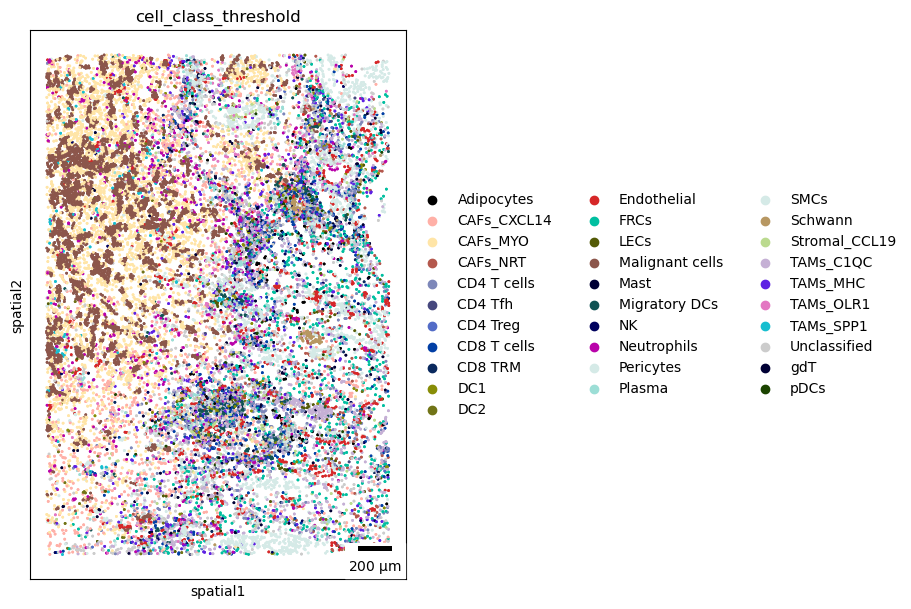

In [31]:
# Spatial distribution of cells
sq.pl.spatial_scatter(
    imm_107_480, shape=None, color=['cell_class_threshold'], size=4, library_id="spatial", figsize=(9, 7), wspace=0.5, 
    scalebar_dx = 1.0,
    scalebar_kwargs={"scale_loc": "bottom", "location": "lower right"},
#    save='Fig5b_spatial.pdf'
)

## DE analysis comparing malignant cell between regions (distant or proximal to TIL)

In [5]:
# add sample_id
# n = 3 unique samples where malignant cells were subset for DE analysis
TIL_106.obs["sample_id"] = "MH106"
TIL_107.obs["sample_id"] = "MH107"
TIL_065.obs["sample_id"] = "MH065"

# combine into one DataFrame 
import pandas as pd
combined_obs = pd.concat([TIL_106.obs, TIL_107.obs, TIL_065.obs])

In [8]:
grouped

,sample_id,Region,HYPOXIA_pathway_score
0,MH065,noTIL,0.222496
1,MH065,wTIL,-0.089222
2,MH106,noTIL,0.542935
3,MH106,wTIL,0.202069
4,MH107,noTIL,0.362537
5,MH107,wTIL,-0.015293


/tmp/ipykernel_15917/3654658098.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_obs.groupby(['sample_id', 'Region'])['HYPOXIA_pathway_score'].mean().reset_index()


Paired t-test p-value: 0.0031


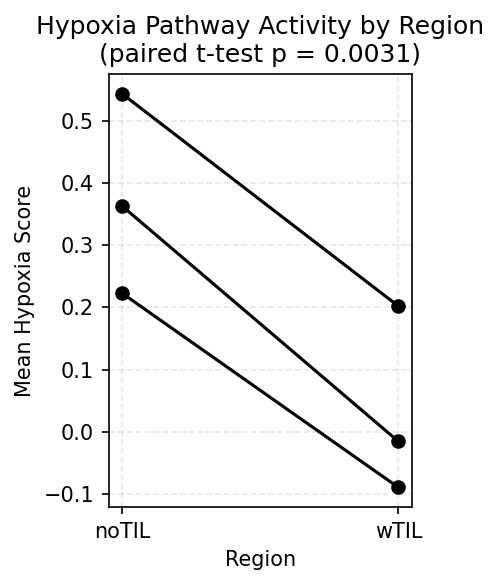

In [7]:
# Compute mean score per Region per Sample
grouped = combined_obs.groupby(['sample_id', 'Region'])['HYPOXIA_pathway_score'].mean().reset_index()

#  Pivot for paired format
pivot = grouped.pivot(index='sample_id', columns='Region', values='HYPOXIA_pathway_score')

# Perform paired t-test
from scipy.stats import ttest_rel
stat, pval = ttest_rel(pivot['wTIL'], pivot['noTIL'])
print(f"Paired t-test p-value: {pval:.4f}")

# Step 4: Plot manually with black lines
plt.figure(figsize=(3, 4), dpi=150)

for sample_id, row in pivot.iterrows():
    plt.plot(['noTIL', 'wTIL'], [row['noTIL'], row['wTIL']], color='black', marker='o', label=sample_id)

plt.ylabel('Mean Hypoxia Score')
plt.xlabel('Region')
plt.title(f'Hypoxia Pathway Activity by Region\n(paired t-test p = {pval:.4f})')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('Hypoxia_score_TIL_Jan26.pdf')
plt.show()

In [14]:
grouped

,sample_id,Region,IL6_pathway_score
0,MH065,noTIL,0.013108
1,MH065,wTIL,0.160845
2,MH106,noTIL,0.053014
3,MH106,wTIL,0.066567
4,MH107,noTIL,0.056981
5,MH107,wTIL,0.161269


Paired t-test p-value: 0.1545


/tmp/ipykernel_14497/661546796.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_obs.groupby(['sample_id', 'Region'])['IL6_pathway_score'].mean().reset_index()


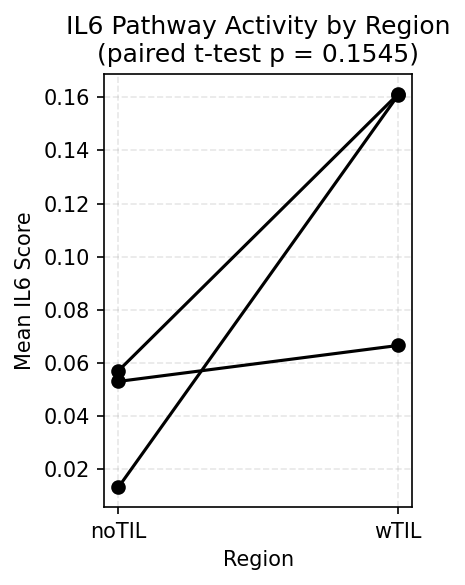

In [24]:
#Compute mean score per Region per Sample
grouped = combined_obs.groupby(['sample_id', 'Region'])['IL6_pathway_score'].mean().reset_index()

#Pivot for paired format
pivot = grouped.pivot(index='sample_id', columns='Region', values='IL6_pathway_score')

# Perform paired t-test
stat, pval = ttest_rel(pivot['wTIL'], pivot['noTIL'])
print(f"Paired t-test p-value: {pval:.4f}")

# Step 4: Plot manually with black lines
plt.figure(figsize=(3, 4), dpi=150)

for sample_id, row in pivot.iterrows():
    plt.plot(['noTIL', 'wTIL'], [row['noTIL'], row['wTIL']], color='black', marker='o', label=sample_id)

plt.ylabel('Mean IL6 Score')
plt.xlabel('Region')
plt.title(f'IL6 Pathway Activity by Region\n(paired t-test p = {pval:.4f})')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
#plt.savefig('IL6_score_TIL.pdf')
plt.show()

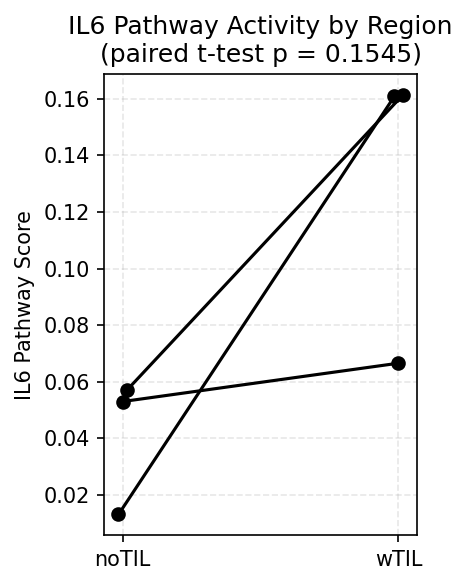

In [25]:
import numpy as np

plt.figure(figsize=(3, 4), dpi=150)

x_vals = [0, 1]  # x-axis positions for 'noTIL' and 'wTIL'

for i, (sample_id, row) in enumerate(pivot.iterrows()):
    jitter = (i - 1) * 0.015  # e.g. –0.05, 0.0, 0.05
    plt.plot([x + jitter for x in x_vals], [row['noTIL'], row['wTIL']],
             color='black', marker='o', label=sample_id)

plt.xticks([0, 1], ['noTIL', 'wTIL'])
plt.ylabel('IL6 Pathway Score')
plt.title(f'IL6 Pathway Activity by Region\n(paired t-test p = {pval:.4f})')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('IL6_score_TIL_.pdf')
plt.show()


In [16]:
grouped

,sample_id,Region,OXPHOS_pathway_score
0,MH065,noTIL,-0.182429
1,MH065,wTIL,-0.061305
2,MH106,noTIL,-0.340960
3,MH106,wTIL,-0.314693
4,MH107,noTIL,-0.044739
5,MH107,wTIL,0.015326


Paired t-test p-value: 0.1303


/tmp/ipykernel_14497/2652565098.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = combined_obs.groupby(['sample_id', 'Region'])['OXPHOS_pathway_score'].mean().reset_index()


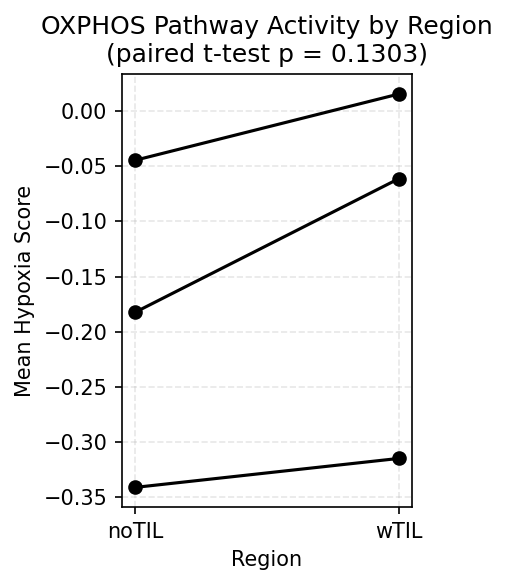

In [26]:
# Compute mean score per Region per Sample
grouped = combined_obs.groupby(['sample_id', 'Region'])['OXPHOS_pathway_score'].mean().reset_index()

# Pivot for paired format
pivot = grouped.pivot(index='sample_id', columns='Region', values='OXPHOS_pathway_score')

# Perform paired t-test
stat, pval = ttest_rel(pivot['wTIL'], pivot['noTIL'])
print(f"Paired t-test p-value: {pval:.4f}")

# Plot manually with black lines
plt.figure(figsize=(3, 4), dpi=150)

for sample_id, row in pivot.iterrows():
    plt.plot(['noTIL', 'wTIL'], [row['noTIL'], row['wTIL']], color='black', marker='o', label=sample_id)

plt.ylabel('Mean Hypoxia Score')
plt.xlabel('Region')
plt.title(f'OXPHOS Pathway Activity by Region\n(paired t-test p = {pval:.4f})')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('OXPHOS_score_TIL_Jan26.pdf')
plt.show()

In [ ]:
# Compute distance between malignant cells to immune cells

In [23]:
from scipy.spatial import cKDTree
# Define immune cell types of interest
immune_types = ['CD4 T cells','CD4 Tfh', 'CD4 Treg', 'CD8 T cells', 'CD8 TRM']

# Get immune cells in the TIL region 
til_mask = imm_106_480.obs['cell_class_threshold'].isin(immune_types)
til_coords = imm_106_480.obsm['spatial'][til_mask] 

# Build KDTree from TIL coordinates
til_tree = cKDTree(til_coords)

In [25]:
# Extract coordinates for each region group
noTIL_coords = TIL_106.obsm['spatial'][TIL_106.obs["Region"] == "noTIL"]
wTIL_coords = TIL_106.obsm['spatial'][TIL_106.obs["Region"] == "wTIL"]

In [26]:
# Compute distances to nearest immune cell
distances_group1, _ = til_tree.query(noTIL_coords, k=1)
distances_group2, _ = til_tree.query(wTIL_coords, k=1)

##### Sample MH106

In [27]:
import numpy as np

median_group1 = np.median(distances_group1)
median_group2 = np.median(distances_group2)

print("Median distance (group 1):", median_group1, "μm")
print("Median distance (group 2):", median_group2, "μm") # MH106

Median distance (group 1): 2392.312708037203 μm
Median distance (group 2): 98.70742240877411 μm


##### Sample MH107

In [15]:
import numpy as np

median_group1 = np.median(distances_group1)
median_group2 = np.median(distances_group2)

print("Median distance (group 1):", median_group1, "μm")
print("Median distance (group 2):", median_group2, "μm") # MH107

Median distance (group 1): 1440.2560910581776 μm
Median distance (group 2): 82.61163749224737 μm


##### Sample MH065

In [21]:
import numpy as np

median_group1 = np.median(distances_group1)
median_group2 = np.median(distances_group2)

print("Median distance (group 1):", median_group1, "μm")
print("Median distance (group 2):", median_group2, "μm") # MH065

Median distance (group 1): 1552.1045790375972 μm
Median distance (group 2): 53.878559576246275 μm
